# Data Explorationn and Processing before Training

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
data = pd.read_csv('/Users/phillippham/Desktop/XAI-BlackBox_Project/Data/adult.csv', delimiter=',')

# Drop 'fnlwgt' column as it's not needed for analysis
data.drop('fnlwgt', axis=1, inplace=True)

# Replace '?' with NaN
data.replace('?', np.nan, inplace=True)

# Display the first 5 rows of the dataset
data.head()

,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [64]:
# See all education levels and their numeric mappings
education_mapping = data[['education', 'education.num']].drop_duplicates().sort_values('education.num')
print(education_mapping)

         education  education.num
1106     Preschool              1
26         1st-4th              2
27         5th-6th              3
3          7th-8th              4
197            9th              5
6             10th              6
16            11th              7
178           12th              8
0          HS-grad              9
2     Some-college             10
25       Assoc-voc             11
18      Assoc-acdm             12
12       Bachelors             13
13         Masters             14
11     Prof-school             15
7        Doctorate             16


In [65]:
data['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [66]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   education       32561 non-null  object
 3   education.num   32561 non-null  int64 
 4   marital.status  32561 non-null  object
 5   occupation      30718 non-null  object
 6   relationship    32561 non-null  object
 7   race            32561 non-null  object
 8   sex             32561 non-null  object
 9   capital.gain    32561 non-null  int64 
 10  capital.loss    32561 non-null  int64 
 11  hours.per.week  32561 non-null  int64 
 12  native.country  31978 non-null  object
 13  income          32561 non-null  object
dtypes: int64(5), object(9)
memory usage: 3.5+ MB


In [67]:
categorical_cols = data.select_dtypes(include=["object"]).columns
print(categorical_cols)

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='object')


In [83]:
# One hot encode categorical variables and label encode the target variable
X = data.drop(['income', 'education'], axis=1)
X = pd.get_dummies(X, drop_first=True)

le = LabelEncoder()
y = le.fit_transform(data['income'])

print(y[:5])  # Print the first 5 encoded labels

[0 0 0 0 0]


# Train / Test split of dataset

In [120]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the XGBoost model
model = XGBClassifier(n_estimators=260, max_depth=6, learning_rate=0.05, objective='binary:logistic')

# Fit model
start_time = time.time()
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
training_time = time.time() - start_time


# Predict on the test set
start_time = time.time()
y_pred = model.predict(X_test)
prediction_time = time.time() - start_time

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print(f'Training Time: {training_time:.2f} seconds')
print(f'Prediction Time: {prediction_time:.2f} seconds')
print(f'Accuracy: {accuracy:.4f}')

# Confusion Matrix
print("\nConfusion Matrix: ")
print(f"                Predicted <=50k (0)  Predicted >50k (1)")
print(f"Actual <=50k (0)       {conf_matrix[0][0]:5d}                    {conf_matrix[0][1]:5d}")
print(f"Actual >50k (1)        {conf_matrix[1][0]:5d}                    {conf_matrix[1][1]:5d}")

print(f"\nTrue Negative: {conf_matrix[0][0]}")
print(f"False Positive: {conf_matrix[0][1]}")
print(f"False Negative: {conf_matrix[1][0]}")
print(f"True Positive: {conf_matrix[1][1]}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Training Time: 0.98 seconds
Prediction Time: 0.01 seconds
Accuracy: 0.8730

Confusion Matrix: 
                Predicted <=50k (0)  Predicted >50k (1)
Actual <=50k (0)        4722                      254
Actual >50k (1)          573                      964

True Negative: 4722
False Positive: 254
False Negative: 573
True Positive: 964

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      4976
           1       0.79      0.63      0.70      1537

    accuracy                           0.87      6513
   macro avg       0.84      0.79      0.81      6513
weighted avg       0.87      0.87      0.87      6513



# Plots and Graphs

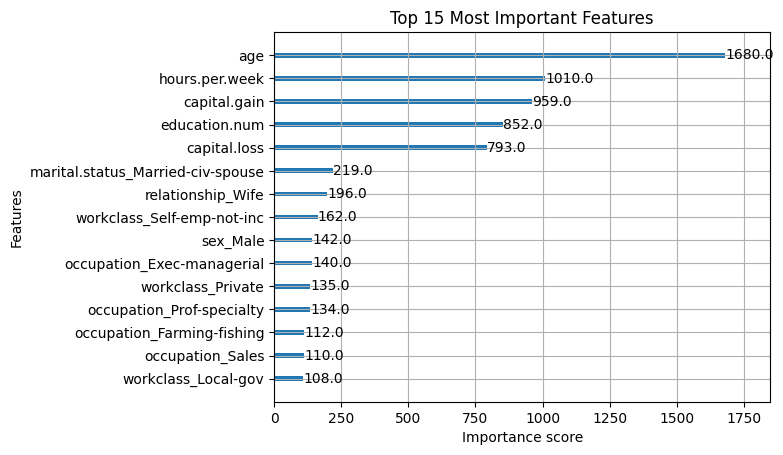

In [121]:
# Plot importance of features
xgb.plot_importance(model, max_num_features=15)
plt.title('Top 15 Most Important Features')
plt.show()

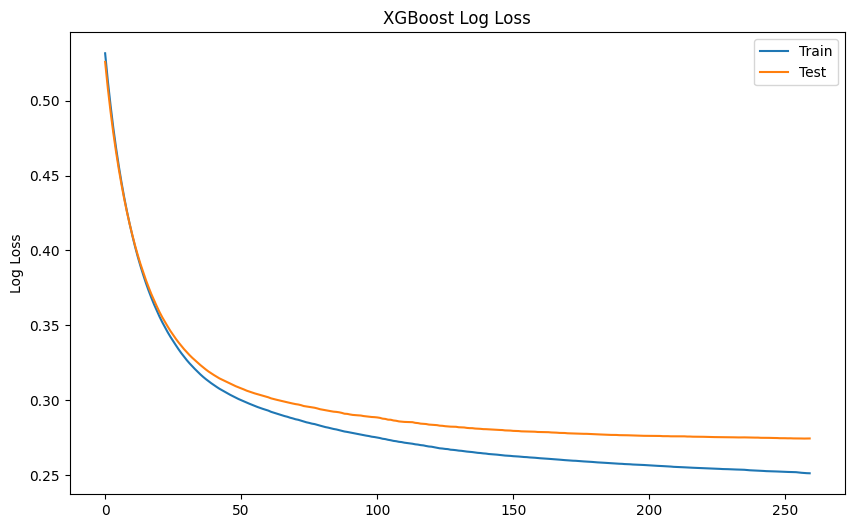

In [122]:
# Plot to show if there's overfitting
results = model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)
plt.figure(figsize=(10, 6))
plt.plot(x_axis, results['validation_0']['logloss'], label='Train')
plt.plot(x_axis, results['validation_1']['logloss'], label='Test')
plt.legend()
plt.ylabel('Log Loss')
plt.title('XGBoost Log Loss')
plt.show()